In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=load_iris()
X=data.data
y=data.target

In [3]:
train_sizes,train_scores,val_scores=learning_curve(
    LogisticRegression(max_iter=1000),
    X,y,
    cv=5,train_sizes=np.linspace(0.1,1.0,10))
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

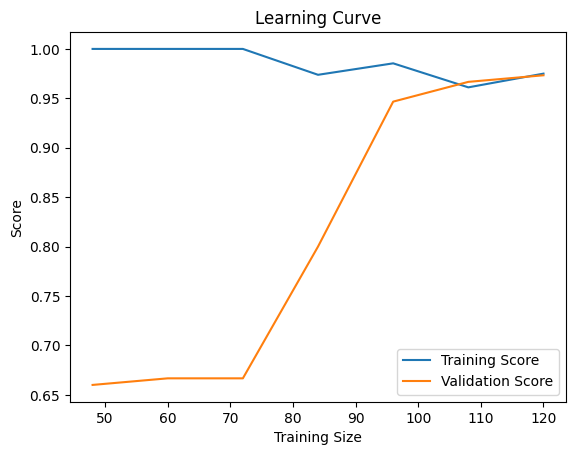

In [4]:
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [7]:
## KFold
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold,StratifiedKFold,RepeatedKFold,cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

In [8]:
X,y=load_iris(return_X_y=True)

In [12]:
kf=KFold(n_splits=5,shuffle=True,random_state=42)
model=LogisticRegression(max_iter=1000)
scores_kf=cross_val_score(model,X,y,cv=kf)
print("K-Fold Scores:",scores_kf)
print("K-Fold Mean:",scores_kf.mean())

K-Fold Scores: [1.         1.         0.93333333 0.96666667 0.96666667]
K-Fold Mean: 0.9733333333333334


In [14]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores_skf=cross_val_score(model,X,y,cv=skf)
print("Stratified k-Fold Scores:",scores_skf)
print("Stratified Mean:",scores_skf.mean())

Stratified k-Fold Scores: [1.         0.96666667 0.93333333 1.         0.93333333]
Stratified Mean: 0.9666666666666668


In [16]:
rkf=RepeatedKFold(n_splits=5,n_repeats=3,random_state=42)
scores_rkf=cross_val_score(model,X,y,cv=rkf)
print("Repeated K_Fold Scores:",scores_rkf)
print("repeated Mean:",scores_rkf.mean())

Repeated K_Fold Scores: [1.         1.         0.93333333 0.96666667 0.96666667 0.96666667
 1.         0.93333333 1.         0.93333333 0.96666667 0.9
 1.         1.         0.96666667]
repeated Mean: 0.9688888888888889


In [19]:
## Validation Curve
from sklearn.datasets import load_iris
from sklearn.model_selection import validation_curve
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

In [20]:
X,y=load_iris(return_X_y=True)

In [21]:
param_range=np.arange(1,20)
train_scores,val_scores=validation_curve(
    KNeighborsClassifier(),
    X,y,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="accuracy")
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

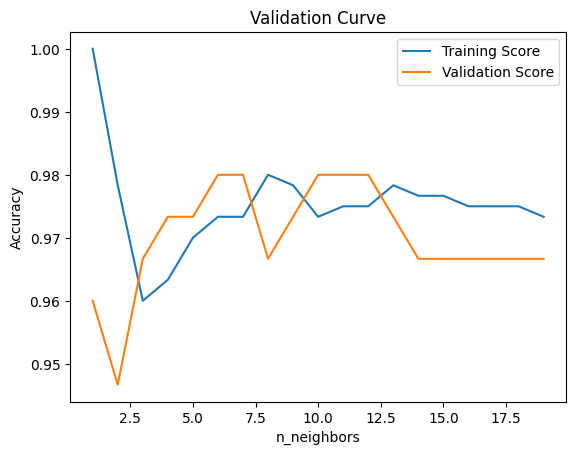

In [22]:
plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")

plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.title("Validation Curve")
plt.legend()
plt.show()